# 🦶 Smartphone Step Detection & Daily Activity Visualization
### Smart City Project — Hadir Helali & Balkis Karoui
Data source: Apple Health Export (iPhone accelerometer)

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
from google.colab import files

# Upload your export.xml file
uploaded = files.upload()  # select your export.xml when prompted

# Parse XML
print("Parsing XML... this may take a moment ⏳")
tree = ET.parse('export.xml')
root = tree.getroot()

# Extract step records
steps = []
for record in root.findall('Record'):
    if record.attrib.get('type') == 'HKQuantityTypeIdentifierStepCount':
        steps.append({
            'startDate': record.attrib.get('startDate'),
            'endDate': record.attrib.get('endDate'),
            'steps': float(record.attrib.get('value')),
            'source': record.attrib.get('sourceName')
        })

df = pd.DataFrame(steps)
df['startDate'] = pd.to_datetime(df['startDate'], utc=True).dt.tz_convert('Europe/Paris')
df['endDate'] = pd.to_datetime(df['endDate'], utc=True).dt.tz_convert('Europe/Paris')
df['date'] = df['startDate'].dt.date
df['hour'] = df['startDate'].dt.hour

print(f"✅ Loaded {len(df)} step records")
print(f"📅 Date range: {df['date'].min()} → {df['date'].max()}")
df.head()

Saving export.xml to export.xml
Parsing XML... this may take a moment ⏳
✅ Loaded 46922 step records
📅 Date range: 2022-04-20 → 2026-04-22


,startDate,endDate,steps,source,date,hour
0,2024-05-15 21:30:52+02:00,2024-05-15 21:40:51+02:00,87.0,iPhone de Hadir,2024-05-15,21
1,2024-05-15 21:40:51+02:00,2024-05-15 21:48:24+02:00,324.0,iPhone de Hadir,2024-05-15,21
2,2024-05-15 22:04:58+02:00,2024-05-15 22:13:12+02:00,818.0,iPhone de Hadir,2024-05-15,22
3,2024-05-01 12:46:19+02:00,2024-05-01 12:47:28+02:00,24.0,iPhone de Hadir,2024-05-01,12
4,2024-05-01 12:58:02+02:00,2024-05-01 12:58:10+02:00,15.0,iPhone de Hadir,2024-05-01,12


Daily Step Totals

In [2]:
# Aggregate steps per day
daily_steps = df.groupby('date')['steps'].sum().reset_index()
daily_steps.columns = ['date', 'total_steps']
daily_steps['date'] = pd.to_datetime(daily_steps['date'])

print(f"📊 Total days tracked: {len(daily_steps)}")
print(f"🏆 Best day: {daily_steps.loc[daily_steps['total_steps'].idxmax(), 'date'].date()} "
      f"— {int(daily_steps['total_steps'].max()):,} steps")
print(f"📈 Average daily steps: {int(daily_steps['total_steps'].mean()):,}")
daily_steps.tail(10)

📊 Total days tracked: 1457
🏆 Best day: 2022-11-06 — 35,526 steps
📈 Average daily steps: 7,556


,date,total_steps
1447,2026-04-13,479.0
1448,2026-04-14,10976.0
1449,2026-04-15,12512.0
1450,2026-04-16,13947.0
1451,2026-04-17,4708.0
1452,2026-04-18,16906.0
1453,2026-04-19,4942.0
1454,2026-04-20,7532.0
1455,2026-04-21,5361.0
1456,2026-04-22,7775.0


Chart 1: Daily Steps Bar Chart

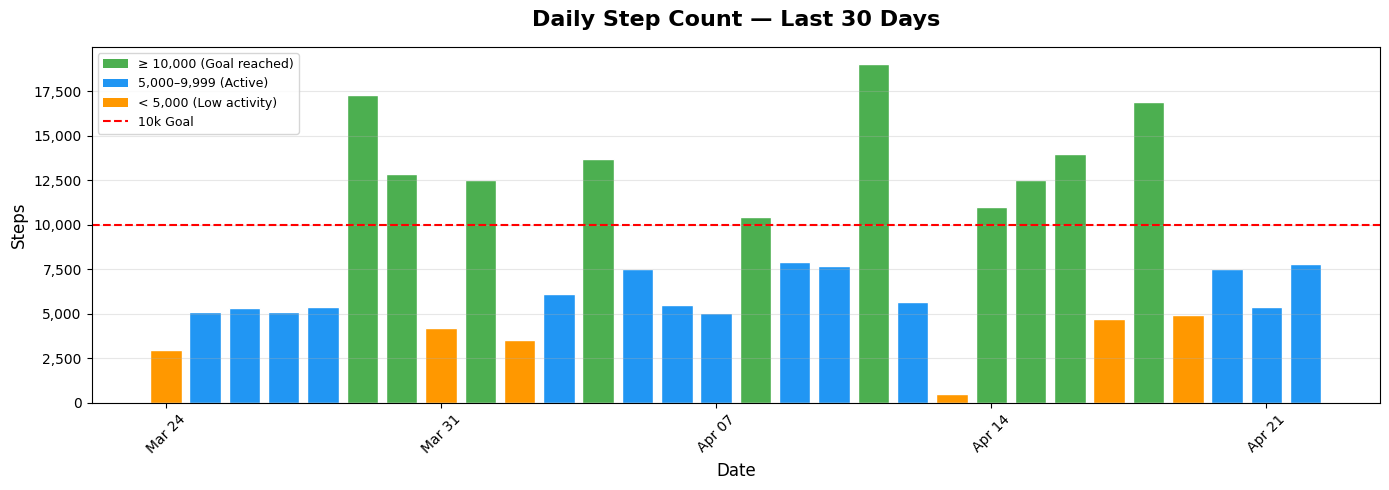

✅ Saved as daily_steps.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use last 30 days for clarity
last30 = daily_steps.tail(30).copy()

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#4CAF50' if s >= 10000 else '#2196F3' if s >= 5000 else '#FF9800'
          for s in last30['total_steps']]

bars = ax.bar(last30['date'], last30['total_steps'], color=colors, width=0.8, edgecolor='white')

# Goal line at 10,000 steps
ax.axhline(y=10000, color='red', linestyle='--', linewidth=1.5, label='Goal: 10,000 steps')

ax.set_title('Daily Step Count — Last 30 Days', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Steps', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='≥ 10,000 (Goal reached)'),
                   Patch(facecolor='#2196F3', label='5,000–9,999 (Active)'),
                   Patch(facecolor='#FF9800', label='< 5,000 (Low activity)')]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='red', linestyle='--', label='10k Goal')],
          loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('daily_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as daily_steps.png")

 Chart 2: Average Steps by Hour of Day

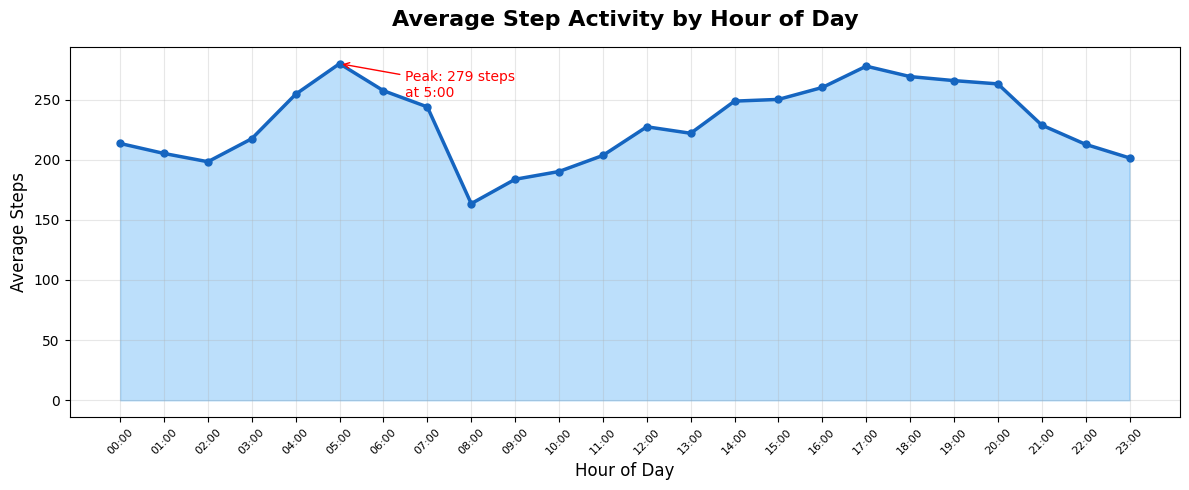

✅ Saved as hourly_steps.png


In [4]:
hourly_avg = df.groupby('hour')['steps'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(hourly_avg['hour'], hourly_avg['steps'], alpha=0.3, color='#2196F3')
ax.plot(hourly_avg['hour'], hourly_avg['steps'], color='#1565C0', linewidth=2.5, marker='o', markersize=5)

ax.set_title('Average Step Activity by Hour of Day', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Steps', fontsize=12)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
ax.grid(alpha=0.3)

# Annotate peak hour
peak_hour = hourly_avg.loc[hourly_avg['steps'].idxmax(), 'hour']
peak_val = hourly_avg['steps'].max()
ax.annotate(f'Peak: {int(peak_val)} steps\nat {peak_hour}:00',
            xy=(peak_hour, peak_val),
            xytext=(peak_hour + 1.5, peak_val * 0.9),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.savefig('hourly_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as hourly_steps.png")

Chart 3: Weekly Trend (Rolling Average)

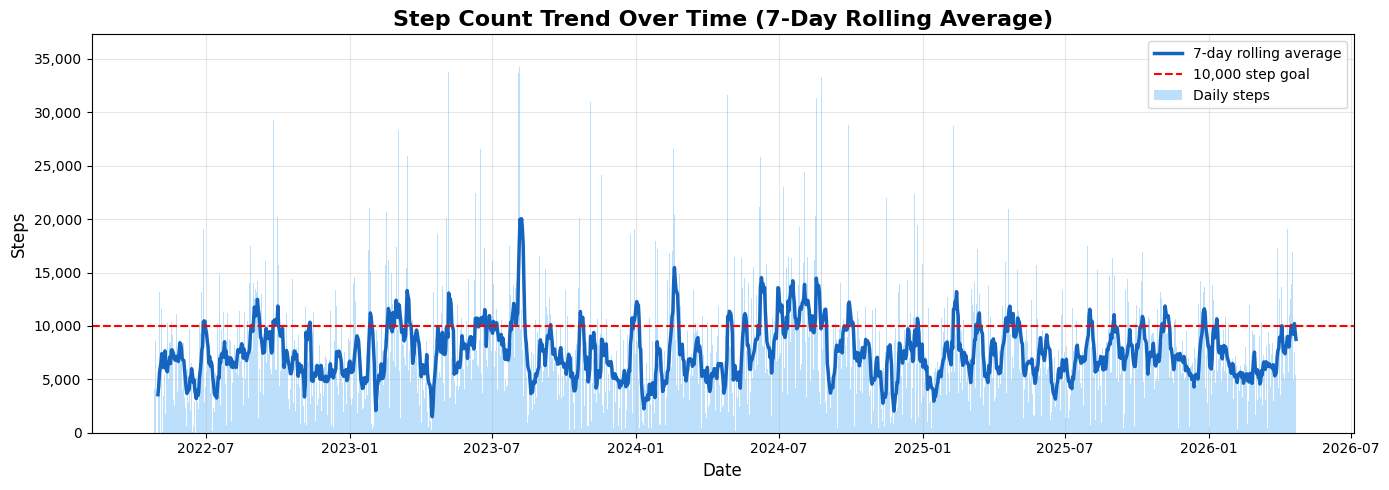

✅ Saved as weekly_trend.png


In [5]:
daily_steps_indexed = daily_steps.set_index('date').sort_index()
daily_steps_indexed['rolling_7'] = daily_steps_indexed['total_steps'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(daily_steps_indexed.index, daily_steps_indexed['total_steps'],
       color='#90CAF9', alpha=0.6, label='Daily steps', width=1)
ax.plot(daily_steps_indexed.index, daily_steps_indexed['rolling_7'],
        color='#1565C0', linewidth=2.5, label='7-day rolling average')
ax.axhline(y=10000, color='red', linestyle='--', linewidth=1.5, label='10,000 step goal')

ax.set_title('Step Count Trend Over Time (7-Day Rolling Average)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Steps', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weekly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as weekly_trend.png")

 Summary Statistics (for your slides)

In [6]:
print("=" * 45)
print("   📊 PROJECT DATA SUMMARY")
print("=" * 45)
print(f"  Total records collected : {len(df):,}")
print(f"  Days tracked            : {len(daily_steps):,}")
print(f"  Date range              : {daily_steps['date'].min().date()} → {daily_steps['date'].max().date()}")
print(f"  Average steps/day       : {int(daily_steps['total_steps'].mean()):,}")
print(f"  Best day (steps)        : {int(daily_steps['total_steps'].max()):,}")
print(f"  Days hitting 10k goal   : {(daily_steps['total_steps'] >= 10000).sum()}")
print(f"  Peak activity hour      : {peak_hour}:00")
print("=" * 45)

   📊 PROJECT DATA SUMMARY
  Total records collected : 46,922
  Days tracked            : 1,457
  Date range              : 2022-04-20 → 2026-04-22
  Average steps/day       : 7,556
  Best day (steps)        : 35,526
  Days hitting 10k goal   : 339
  Peak activity hour      : 5:00


In [7]:
import requests
import json

# This simulates sending step data to your Flask server
# When running locally, use: SERVER_URL = "http://localhost:5000"
# For demo purposes, we show the payload that would be sent

daily_payload = daily_steps.tail(7).copy()
daily_payload['date'] = daily_payload['date'].astype(str)

payload = {
    "device": "iPhone (Hadir)",
    "sensor": "HKQuantityTypeIdentifierStepCount",
    "data": daily_payload.rename(columns={'total_steps':'steps'}).to_dict(orient='records')
}

print("📡 Payload ready to send to cloud server:")
print(json.dumps(payload, indent=2))
print("\n✅ In production: requests.post('http://your-server/api/daily', json=payload)")

📡 Payload ready to send to cloud server:
{
  "device": "iPhone (Hadir)",
  "sensor": "HKQuantityTypeIdentifierStepCount",
  "data": [
    {
      "date": "2026-04-16",
      "steps": 13947.0
    },
    {
      "date": "2026-04-17",
      "steps": 4708.0
    },
    {
      "date": "2026-04-18",
      "steps": 16906.0
    },
    {
      "date": "2026-04-19",
      "steps": 4942.0
    },
    {
      "date": "2026-04-20",
      "steps": 7532.0
    },
    {
      "date": "2026-04-21",
      "steps": 5361.0
    },
    {
      "date": "2026-04-22",
      "steps": 7775.0
    }
  ]
}

✅ In production: requests.post('http://your-server/api/daily', json=payload)
